In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
Heart_Disease_df=pd.read_csv("../data/Heart_disease.csv")

In [11]:
print(Heart_Disease_df.index)
print(Heart_Disease_df.head(10))

RangeIndex(start=0, stop=303, step=1)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   0       145   233    1        2      150      0      2.3      2   
1   67    1   3       160   286    0        2      108      1      1.5      1   
2   67    1   3       120   229    0        2      129      1      2.6      1   
3   37    1   2       130   250    0        0      187      0      3.5      2   
4   41    0   1       130   204    0        2      172      0      1.4      0   
5   56    1   1       120   236    0        0      178      0      0.8      0   
6   62    0   3       140   268    0        2      160      0      3.6      2   
7   57    0   3       120   354    0        0      163      1      0.6      0   
8   63    1   3       130   254    0        2      147      0      1.4      1   
9   53    1   3       140   203    1        2      155      1      3.1      2   

   ca  thal  target  
0   0     2       0  
1   3     1       1  
2   

In [12]:
print(Heart_Disease_df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [13]:
print(Heart_Disease_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


In [14]:
print(Heart_Disease_df.isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [15]:
print(Heart_Disease_df["target"].value_counts())

target
0    164
1    139
Name: count, dtype: int64


In [16]:
Heart_Disease_df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


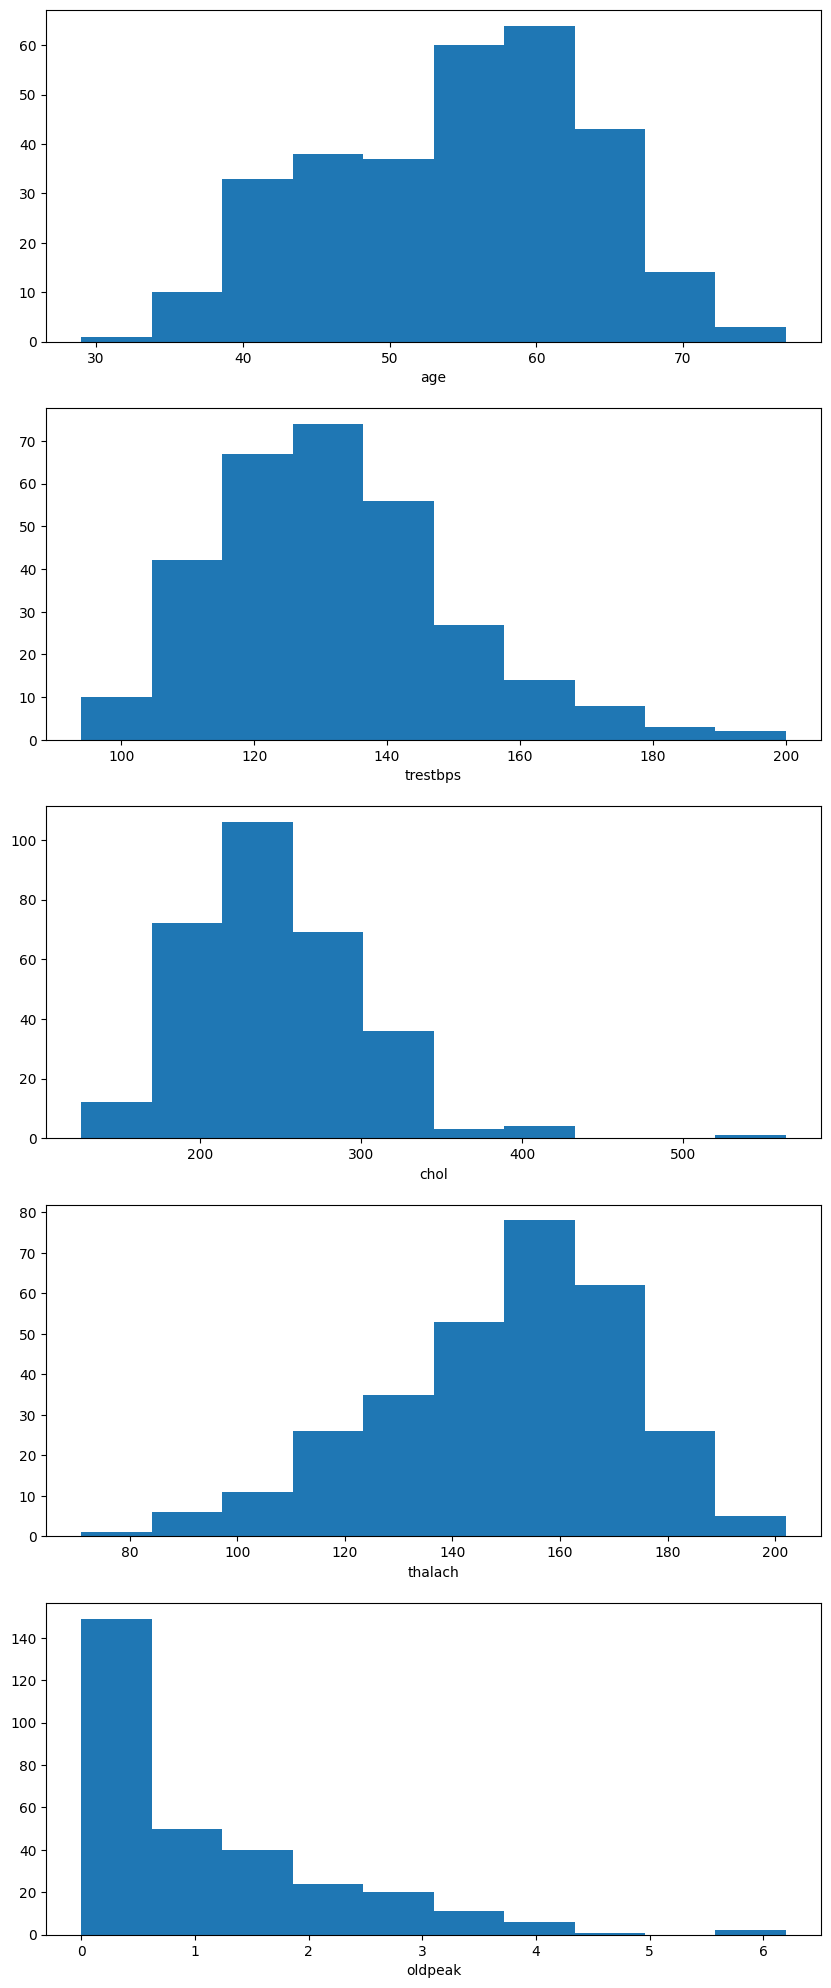

In [17]:
numeric_features=["age","trestbps","chol","thalach","oldpeak"]
fig , ax = plt.subplots(5,1)
for fetur in range(0,5):
    ax[fetur].hist(Heart_Disease_df[numeric_features[fetur]])
    ax[fetur].set_xlabel(numeric_features[fetur])
fig.set_size_inches([10,25])
plt.show()

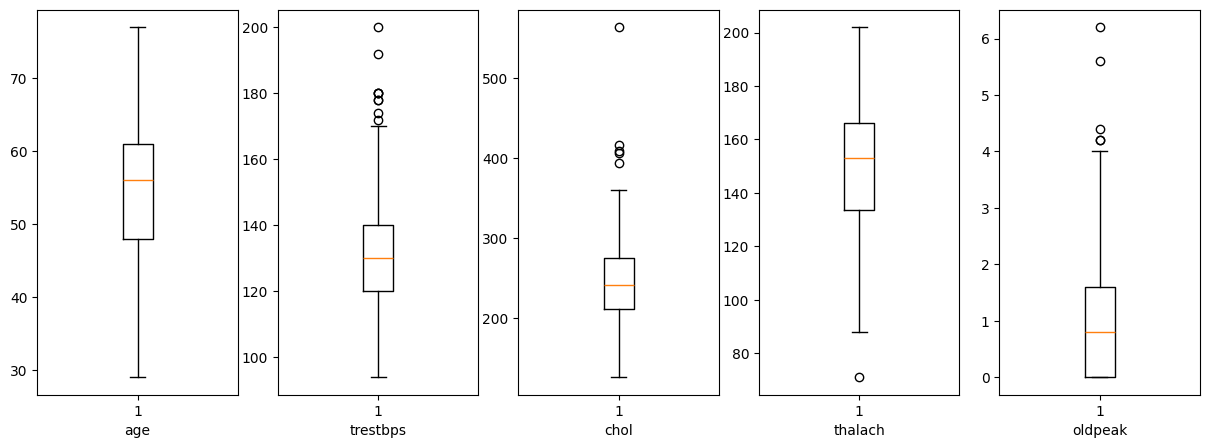

In [18]:
fig , ax = plt.subplots(1,5)
for fetur in range(0,5):
    ax[fetur].boxplot(Heart_Disease_df[numeric_features[fetur]])
    ax[fetur].set_xlabel(numeric_features[fetur])
fig.set_size_inches([15,5])
plt.show()

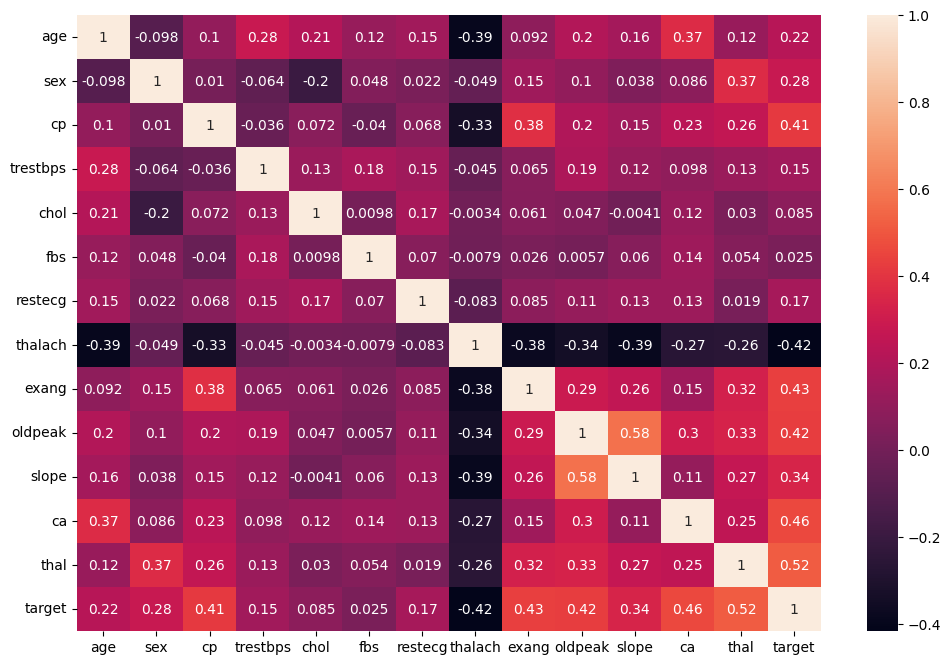

In [19]:
plt.figure(figsize=(12, 8))
sns.heatmap(Heart_Disease_df.corr(),annot=True)
plt.show()

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,roc_curve

In [21]:
X=Heart_Disease_df.drop("target",axis=1).values
y=Heart_Disease_df["target"].values
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

In [22]:
steps=[("scaling",StandardScaler()),
        ("logistic_regression",LogisticRegression())]
pipeline=Pipeline(steps)
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)
report=classification_report(y_test,y_pred,output_dict=True)
report_df=pd.DataFrame(report).transpose()
report_df.to_csv("../results/heart/heart_logistic_regression_report.csv")

In [23]:
steps=[("scaling",StandardScaler()),
        ("svm",SVC(kernel='rbf'))]
pipeline=Pipeline(steps)
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)
pipeline.score(X_test,y_test)
report=classification_report(y_test,y_pred,output_dict=True)
report_df=pd.DataFrame(report).transpose()
report_df.to_csv("../results/heart/heart_SVM_report.csv")

In [24]:
import os
__file__="DiseasePrediction"
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
data=model_file = os.path.join(BASE_DIR, "models", "heart_pipline.pkl")

In [25]:
import joblib
joblib.dump(pipeline,model_file)

['C:\\CodeAlphaML\\DiseasePrediction\\models\\heart_pipline.pkl']

In [26]:
steps=[("scaling",StandardScaler()),
        ("random_forest",RandomForestClassifier(n_estimators=100,random_state=42))]
pipeline=Pipeline(steps)
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)
pipeline.score(X_test,y_test)
report=classification_report(y_test,y_pred,output_dict=True)
report_df=pd.DataFrame(report).transpose()
report_df.to_csv("../results/heart/heart_RandomForest_report.csv")

In [28]:
steps=[("scaling",StandardScaler()),
        ("xgboost",XGBClassifier(n_estimators=100))]
pipeline=Pipeline(steps)
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)
pipeline.score(X_test,y_test)
report=classification_report(y_test,y_pred,output_dict=True)
report_df=pd.DataFrame(report).transpose()
report_df.to_csv("../results/heart/heart_XGBoost_report.csv")